<a href="https://colab.research.google.com/github/NataliaUrzagaste/se-ales-y-sistemas/blob/main/practico3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

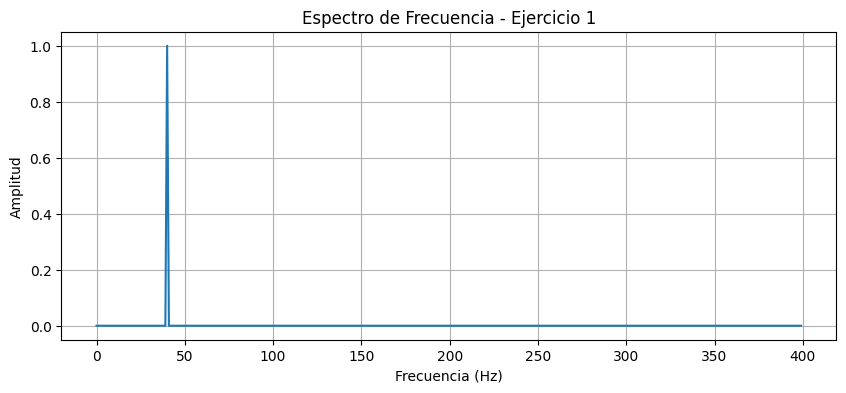

In [ ]:
#EJERCICIO 1
import numpy as np
import matplotlib.pyplot as plt

# Configuración
fs = 800
t = np.arange(0, 1, 1/fs)
f_señal = 40
x = np.sin(2 * np.pi * f_señal * t)

# FFT
n = len(x)
X_fft = np.fft.fft(x)
frecuencias = np.fft.fftfreq(n, 1/fs)

# Graficar
plt.figure(figsize=(10, 4))
plt.plot(frecuencias[:n//2], np.abs(X_fft[:n//2]) * 2 / n)
plt.title("Espectro de Frecuencia - Ejercicio 1")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

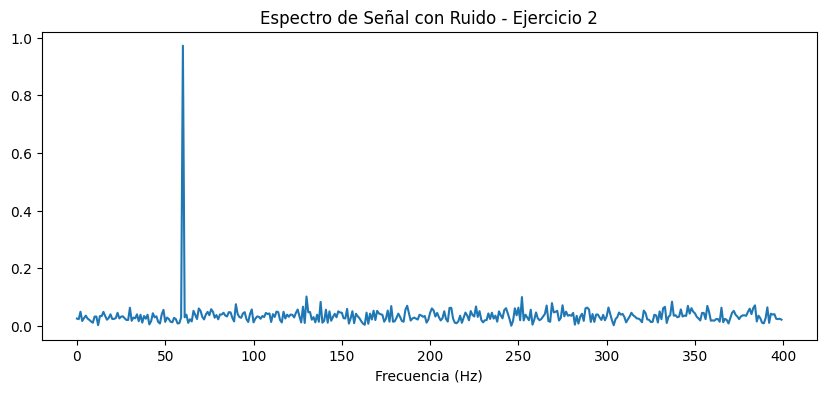

In [ ]:
#EJERCICIO 2
import numpy as np
import matplotlib.pyplot as plt
# Generar señal con ruido
x_ruido = np.sin(2 * np.pi * 60 * t) + 0.5 * np.random.randn(len(t))

X_ruido_fft = np.fft.fft(x_ruido)

plt.figure(figsize=(10, 4))
plt.plot(frecuencias[:n//2], np.abs(X_ruido_fft[:n//2]) * 2 / n)
plt.title("Espectro de Señal con Ruido - Ejercicio 2")
plt.xlabel("Frecuencia (Hz)")
plt.show()

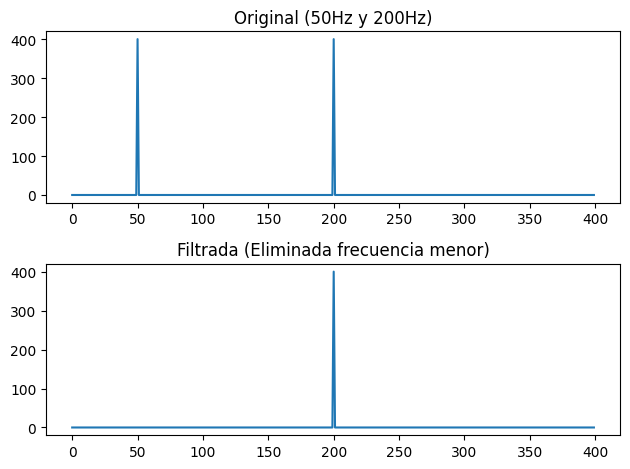

In [ ]:
#EJERCICIO 2
import numpy as np
import matplotlib.pyplot as plt

x3 = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 200 * t)

# FFT y eliminación de la frecuencia menor
X3_fft = np.fft.fft(x3)
# Filtro pasa bajos
X3_filtrada = X3_fft.copy()
X3_filtrada[np.abs(frecuencias) < 100] = 0

plt.subplot(2,1,1)
plt.plot(frecuencias[:n//2], np.abs(X3_fft[:n//2]))
plt.title("Original (50Hz y 200Hz)")

plt.subplot(2,1,2)
plt.plot(frecuencias[:n//2], np.abs(X3_filtrada[:n//2]))
plt.title("Filtrada (Eliminada frecuencia menor)")
plt.tight_layout()
plt.show()

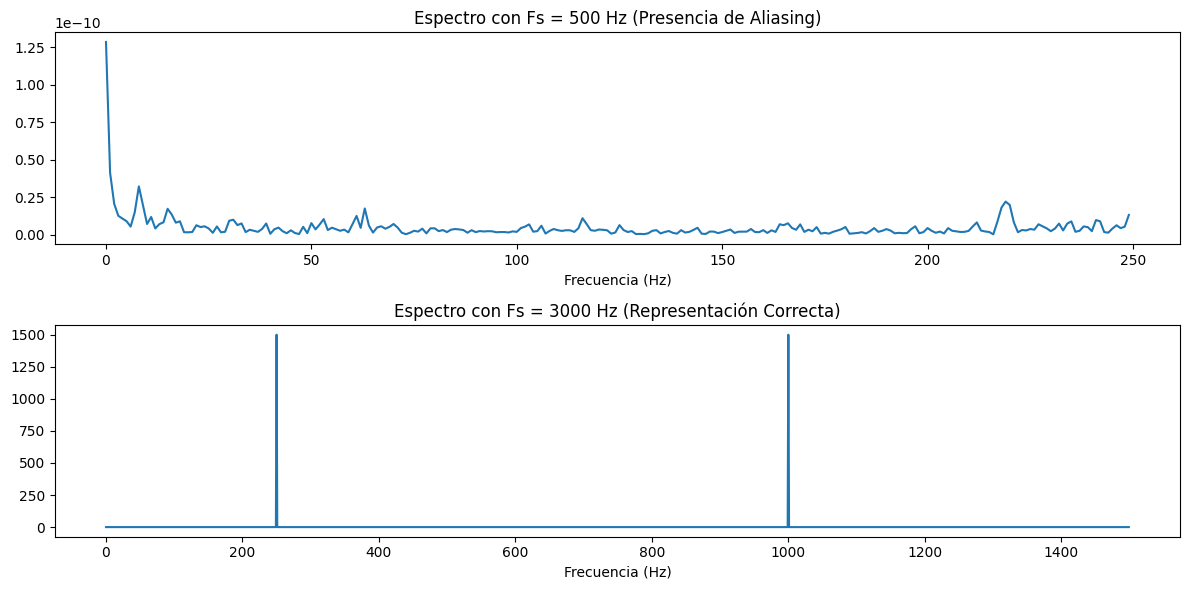

In [ ]:
# EJERCICIO 4
import numpy as np
import matplotlib.pyplot as plt

# Primera frecuencia
fs1 = 500
t1 = np.arange(0, 1, 1/fs1)
f1, f2 = 250, 1000
x1 = np.sin(2 * np.pi * f1 * t1) + np.sin(2 * np.pi * f2 * t1)

X1_fft = np.fft.fft(x1)
freqs1 = np.fft.fftfreq(len(x1), 1/fs1)

# Segunda frecuencia
fs2 = 3000
t2 = np.arange(0, 1, 1/fs2)
x2 = np.sin(2 * np.pi * f1 * t2) + np.sin(2 * np.pi * f2 * t2)

X2_fft = np.fft.fft(x2)
freqs2 = np.fft.fftfreq(len(x2), 1/fs2)

# Graficar
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(freqs1[:len(x1)//2], np.abs(X1_fft[:len(x1)//2]))
plt.title("Espectro con Fs = 500 Hz (Presencia de Aliasing)")
plt.xlabel("Frecuencia (Hz)")

plt.subplot(2, 1, 2)
plt.plot(freqs2[:len(x2)//2], np.abs(X2_fft[:len(x2)//2]))
plt.title("Espectro con Fs = 3000 Hz (Representación Correcta)")
plt.xlabel("Frecuencia (Hz)")

plt.tight_layout()
plt.show()

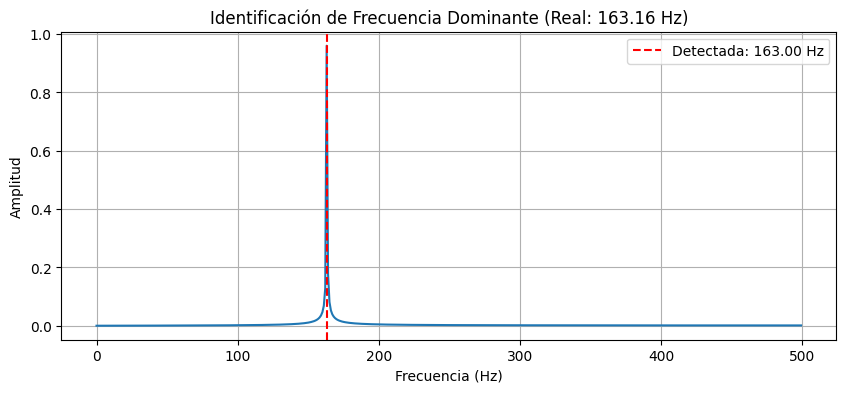

La frecuencia aleatoria generada fue: 163.16 Hz
La frecuencia identificada por la FFT es: 163.00 Hz


In [ ]:
#EJERCICIO 5
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración
fs = 1000
t = np.arange(0, 1, 1/fs)

# 2. Generar frecuencia aleatoria
f_desconocida = np.random.uniform(50, 200)
x = np.sin(2 * np.pi * f_desconocida * t)

n = len(x)
X_fft = np.fft.fft(x)
frecuencias = np.fft.fftfreq(n, 1/fs)

# 4. Encontrar la frecuencia
magnitud = np.abs(X_fft[:n//2]) * 2 / n
indice_maximo = np.argmax(magnitud)
f_detectada = frecuencias[indice_maximo]

# 5. Graficar
plt.figure(figsize=(10, 4))
plt.plot(frecuencias[:n//2], magnitud)
plt.axvline(f_detectada, color='r', linestyle='--', label=f'Detectada: {f_detectada:.2f} Hz')
plt.title(f"Identificación de Frecuencia Dominante (Real: {f_desconocida:.2f} Hz)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()
plt.show()

print(f"La frecuencia aleatoria generada fue: {f_desconocida:.2f} Hz")
print(f"La frecuencia identificada por la FFT es: {f_detectada:.2f} Hz")